<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Thesis/blob/main/A_Hybrid_CNN%E2%80%93EfficientNetB4_Framework_with_Squeeze_and_Excitation_Attention_for_Multi_Class_Skin_Lesion_Classification_on_the_HAM10000_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import AdamW

from sklearn.utils.class_weight import compute_class_weight
import os

In [4]:
DATASET_DIR = "/content/drive/MyDrive/Skin Cancer MNIST HAM10000/split"

TRAIN_PATH = os.path.join(DATASET_DIR, "train")
TEST_PATH  = os.path.join(DATASET_DIR, "test")

In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_generator.num_classes
print("Classes:", train_generator.class_indices)

Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.
Classes: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [7]:
classes = train_generator.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(weights))
print(class_weights)

{0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [8]:
input_layer = Input(shape=(224,224,3))

# =========================
# CNN BRANCH
# =========================
x = Conv2D(32,(3,3),activation='relu',padding='same')(input_layer)
x = BatchNormalization()(x)
x = Conv2D(32,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(64,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(64,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(128,(3,3),activation='relu',padding='same')(x)
x = BatchNormalization()(x)
x = Conv2D(128,(3,3),activation='relu')(x)
x = MaxPooling2D()(x)

x = Conv2D(256,(3,3),activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)

cnn_features = GlobalAveragePooling2D()(x)
cnn_features = Dense(256,activation='relu')(cnn_features)

# =========================
# EfficientNetB4 BRANCH
# =========================
base_model = EfficientNetB4(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

base_model.trainable = True

for layer in base_model.layers[:-80]:
    layer.trainable = False

y = base_model.output

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [9]:
def se_block(input_tensor, ratio=8):

    filters = input_tensor.shape[-1]

    se = GlobalAveragePooling2D()(input_tensor)
    se = Dense(filters//ratio, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1,1,filters))(se)

    return Multiply()([input_tensor, se])

In [10]:
attention = se_block(y)
attention = GlobalAveragePooling2D()(attention)

y = GlobalAveragePooling2D()(y)

y = Dense(512,activation='relu')(y)
y = BatchNormalization()(y)

y = Dense(256,activation='relu')(y)
y = Dropout(0.5)(y)

efficient_features = Dense(256,activation='relu')(y)

In [11]:
combined = Concatenate()([
    cnn_features,
    efficient_features,
    attention
])

z = Dense(512,activation='relu')(combined)
z = BatchNormalization()(z)

z = Dense(256,activation='relu')(z)
z = Dropout(0.5)(z)

z = Dense(128,activation='relu')(z)
z = Dropout(0.4)(z)

output = Dense(NUM_CLASSES, activation='softmax')(z)

model = Model(inputs=input_layer, outputs=output)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,296 │ stem_conv_pad[0]… │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        192 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        432 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        192 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 48)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 48)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 12)  │        588 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 48)  │        624 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 48)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      1,152 │ block1a_se_excit

 Total params: 21,593,062 (82.37 MB)

 Trainable params: 13,115,079 (50.03 MB)

 Non-trainable params: 8,477,983 (32.34 MB)

In [12]:
optimizer = AdamW(
    learning_rate=3e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_HAM10000_Hybrid_EfficientNetB4.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [14]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.2439 - loss: 2.2303 
Epoch 1: val_accuracy improved from None to 0.36695, saving model to best_HAM10000_Hybrid_EfficientNetB4.keras

Epoch 1: finished saving model to best_HAM10000_Hybrid_EfficientNetB4.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 6297s 25s/step - accuracy: 0.3102 - loss: 2.0549 - val_accuracy: 0.3669 - val_loss: 1.5248 - learning_rate: 3.0000e-04
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.3830 - loss: 1.6129 
Epoch 2: val_accuracy improved from 0.36695 to 0.52921, saving model to best_HAM10000_Hybrid_EfficientNetB4.keras

Epoch 2: finished saving model to best_HAM10000_Hybrid_EfficientNetB4.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 6149s 24s/step - accuracy: 0.4129 - loss: 1.5173 - val_accuracy: 0.5292 - val_loss: 1.1032 - learning_rate: 3.0000e-04
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.4437 - loss: 1.3892 
Epoch 3: val_accuracy improved from 0.52921 to 0.53620, saving mode

In [15]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Final Accuracy:", acc * 100)
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 590s 9s/step - accuracy: 0.6101 - loss: 0.9109
Final Accuracy: 61.00848913192749


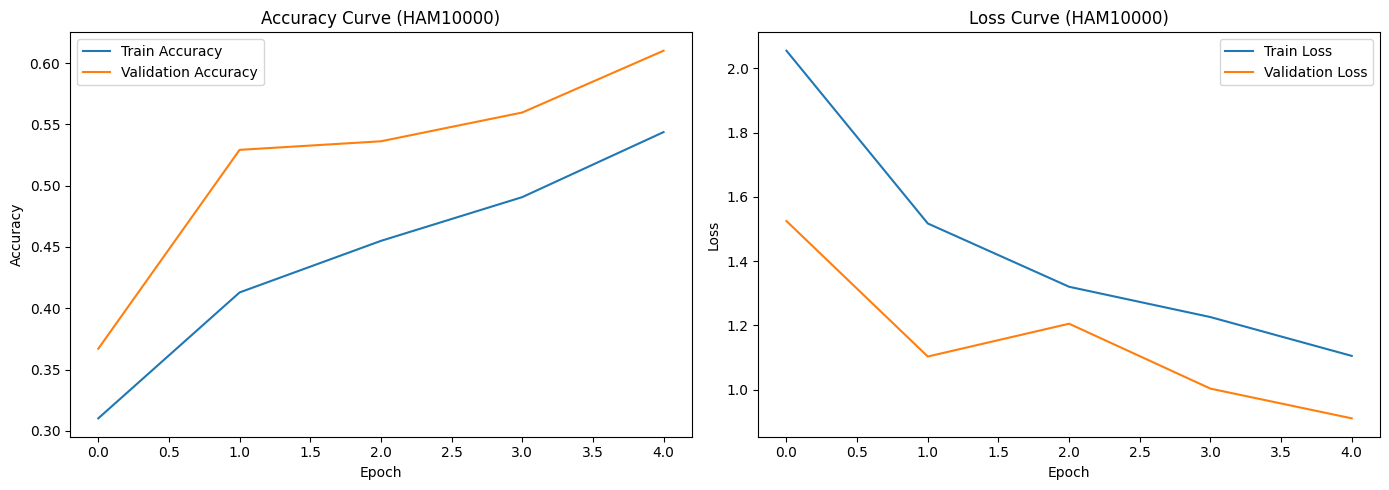

In [16]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve (HAM10000)')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve (HAM10000)')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
y_pred_prob = model.predict(test_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

63/63 ━━━━━━━━━━━━━━━━━━━━ 603s 9s/step


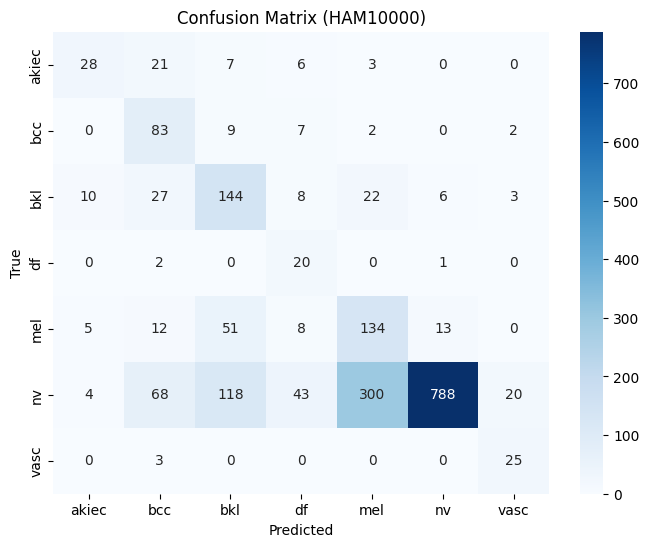

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (HAM10000)")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       akiec       0.60      0.43      0.50        65
         bcc       0.38      0.81      0.52       103
         bkl       0.44      0.65      0.52       220
          df       0.22      0.87      0.35        23
         mel       0.29      0.60      0.39       223
          nv       0.98      0.59      0.73      1341
        vasc       0.50      0.89      0.64        28

    accuracy                           0.61      2003
   macro avg       0.49      0.69      0.52      2003
weighted avg       0.78      0.61      0.65      2003



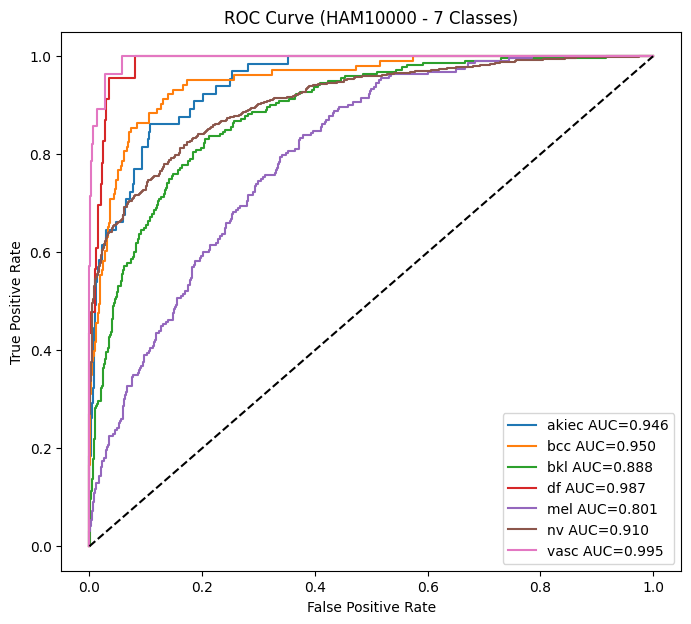

In [20]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

n_classes = len(class_names)

y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

plt.figure(figsize=(8,7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{class_names[i]} AUC={roc_auc:.3f}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (HAM10000 - 7 Classes)")
plt.legend()
plt.show()

In [21]:
print("\nAUC VALUES\n")

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)

    print(class_names[i], ":", round(roc_auc, 4))


AUC VALUES

akiec : 0.9456
bcc : 0.9505
bkl : 0.8883
df : 0.9867
mel : 0.801
nv : 0.91
vasc : 0.9947


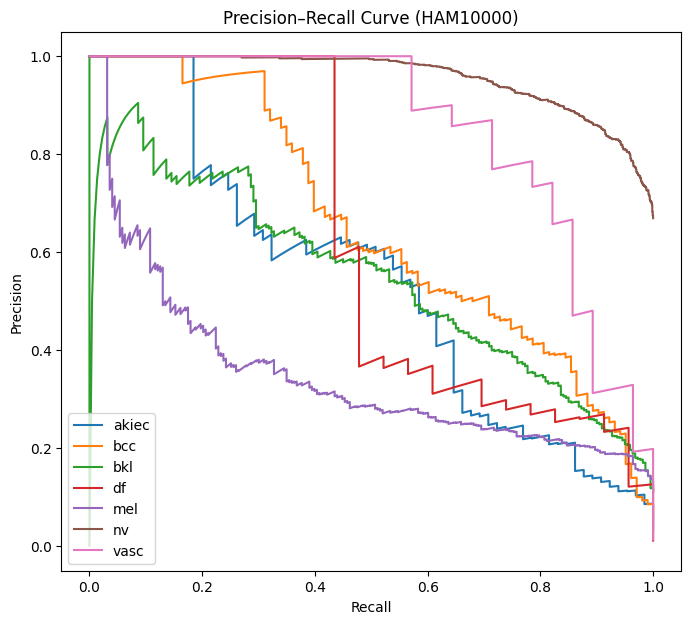

In [22]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,7))

for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(recall, precision, label=class_names[i])

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (HAM10000)")
plt.legend()
plt.show()

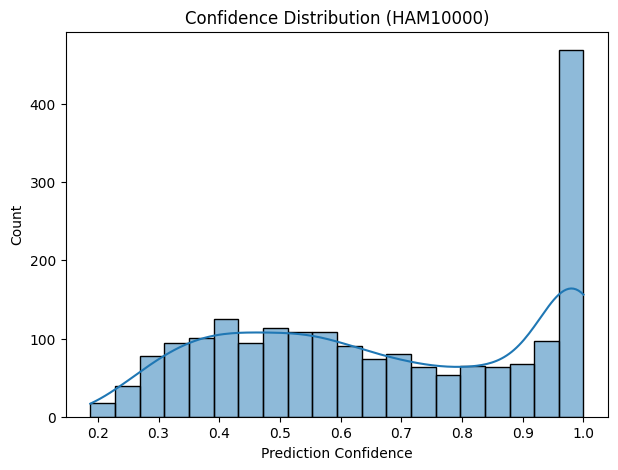

In [23]:
confidence = np.max(y_pred_prob, axis=1)

plt.figure(figsize=(7,5))
sns.histplot(confidence, bins=20, kde=True)

plt.title("Confidence Distribution (HAM10000)")
plt.xlabel("Prediction Confidence")
plt.ylabel("Count")
plt.show()